In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler

from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# ==========================
# LOAD DATA
# ==========================

dataset = pd.read_csv("../dataset/riemann_features.csv")

features = [
"z_co_gram_lag_2",
"z_gram",
"z_gram_lag_1",
"d_lag_13",
"z_co_gram_lag_3",
"z_co_gram_lag_1",
"d_lag_14",
"d_lag_1",
"z_gram_lag_2",
"d_lag_17"
]

X = dataset[features].values
y = dataset["distance"].values

X = X[:2000]
y = y[:2000]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# ==========================
# SCALE
# ==========================

scaler = MinMaxScaler(feature_range=(-1,1))

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# PCA
# ==========================

pca = PCA(n_components=5)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

n_qubits = X_train.shape[1]

# ==========================
# QUANTUM SPECTRAL FEATURE MAP
# ==========================

x = ParameterVector("x", n_qubits)

qc = QuantumCircuit(n_qubits)

# camada inicial
for i in range(n_qubits):
    qc.h(i)

# spectral layers
for layer in range(4):

    for i in range(n_qubits):
        qc.rz(x[i], i)
        qc.rx(0.5 * x[i], i)

    for i in range(n_qubits - 1):
        qc.cz(i, i + 1)

    qc.cz(n_qubits - 1, 0)

# ==========================
# QUANTUM KERNEL
# ==========================

sampler = StatevectorSampler()

fidelity = ComputeUncompute(sampler=sampler)

quantum_kernel = FidelityQuantumKernel(
    feature_map=qc,
    fidelity=fidelity
)

# ==========================
# SVR
# ==========================

svr = SVR(
    kernel=quantum_kernel.evaluate,
    C=20,
    epsilon=0.0005
)

print("Training Quantum Spectral Kernel SVR...")

svr.fit(X_train, y_train)

pred = svr.predict(X_test)

# ==========================
# METRICS
# ==========================

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("\n===== Quantum Spectral Kernel Results =====")
print("RMSE:", rmse)
print("R2:", r2)

Training Quantum Spectral Kernel SVR...

===== Quantum Spectral Kernel Results =====
RMSE: 5.744677799915843
R2: -404.98600522164344



Checking kernel quality...
Kernel mean: 0.08831170625318491
Kernel std: 0.16569549607130962


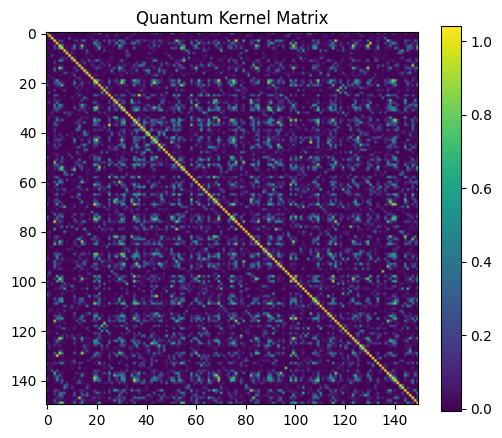


Training Quantum SVR...


KeyboardInterrupt: 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler

from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel


# ==========================
# LOAD DATA
# ==========================

dataset = pd.read_csv("../dataset/riemann_features.csv")

features = [
    "z_co_gram_lag_2",
    "z_gram",
    "z_gram_lag_1",
    "d_lag_13",
    "z_co_gram_lag_3",
    "z_co_gram_lag_1",
    "d_lag_14",
    "d_lag_1",
    "z_gram_lag_2",
    "d_lag_17"
]

X = dataset[features].values
y = dataset["distance"].values

# limitar dataset
X = X[:2000]
y = y[:2000]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# ==========================
# SCALE
# ==========================

scaler = MinMaxScaler(feature_range=(-1, 1))

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================
# PCA
# ==========================

pca = PCA(n_components=5)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

n_qubits = X_train.shape[1]


# ==========================
# CORRECTED SPECTRAL FEATURE MAP
# ==========================

x = ParameterVector("x", n_qubits)

qc = QuantumCircuit(n_qubits)

# camada inicial
for i in range(n_qubits):
    qc.h(i)

# spectral layers corrigidas
for layer in range(2):

    for i in range(n_qubits):
        qc.ry(3 * x[i], i)

    for i in range(n_qubits - 1):
        qc.rzz(x[i] * x[i+1], i, i+1)

    qc.cz(n_qubits - 1, 0)


# ==========================
# QUANTUM KERNEL
# ==========================

sampler = StatevectorSampler()

fidelity = ComputeUncompute(sampler=sampler)

quantum_kernel = FidelityQuantumKernel(
    feature_map=qc,
    fidelity=fidelity
)


# ==========================
# KERNEL DIAGNOSTIC
# ==========================

print("\nChecking kernel quality...")

subset = X_train[:150]

K = quantum_kernel.evaluate(subset)

print("Kernel mean:", np.mean(K))
print("Kernel std:", np.std(K))

if np.std(K) < 0.01:
    print("⚠ WARNING: kernel may be collapsed")


# visualizar matriz de kernel
plt.figure(figsize=(6,5))
plt.imshow(K)
plt.title("Quantum Kernel Matrix")
plt.colorbar()
plt.show()


# ==========================
# SVR
# ==========================

svr = SVR(
    kernel=quantum_kernel.evaluate,
    C=20,
    epsilon=0.0005
)

print("\nTraining Quantum SVR...")

svr.fit(X_train, y_train)

pred = svr.predict(X_test)


# ==========================
# METRICS
# ==========================

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("\n===== RESULTS =====")
print("RMSE:", rmse)
print("R2:", r2)